In [6]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import os

Loading Validation Set and Model...
Total COD Orders in Validation Set: 3231
Baseline Profit (Do Nothing): ₹648,700.00
Optimal Aegis Profit: ₹672,300.00 at Threshold 0.71
Net Value Added by Aegis: +₹23,600.00


/var/folders/pg/6llmvb710lxgx_m35z808cgc0000gn/T/ipykernel_96188/3526779180.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['₹{:,.0f}'.format(x) for x in current_values])


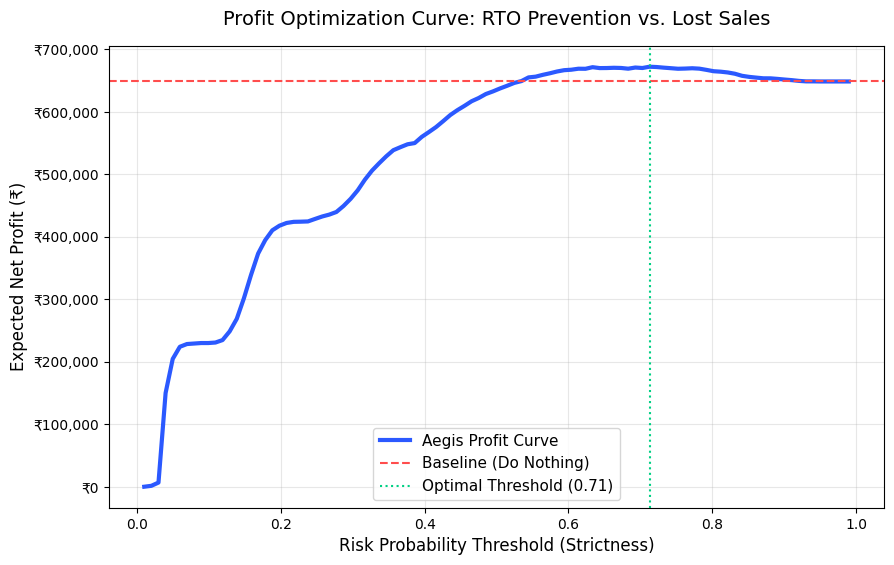


BOOM! Profit Curve saved to artifacts/profit_curve.png
This is the most important slide in your deck.


In [10]:
def generate_profit_curve():
    print("Loading Validation Set and Model...")
    # FIX: Removed __file__ since we are in a Jupyter Notebook
    val_data = pd.read_csv('artifacts/val_set.csv')
    model = joblib.load('artifacts/xgboost_model.pkl')
    
    # We are isolating COD orders because Prepaid orders don't have RTO risk
    cod_mask = val_data['payment_method'] == 0 # Assuming 0 is COD from our encoding
    val_cod = val_data[cod_mask].copy()
    
    X_val_cod = val_cod.drop(columns=['true_label'])
    y_val_cod = val_cod['true_label']
    
    # Get raw probabilities
    # Column 2 is the probability of Logistics/Intent RTO
    rto_probs = model.predict_proba(X_val_cod)[:, 2] 
    
    # --- THE FINANCIAL COST MATRIX ---
    AOV = 2000          # Average Order Value
    MARGIN = 400        # Merchant Profit per successful order
    RTO_COST = 150      # Shipping/Packaging loss when an order is returned
    
    print(f"Total COD Orders in Validation Set: {len(val_cod)}")
    
    thresholds = np.linspace(0.01, 0.99, 100)
    profits = []
    
    # Baseline: "Do Nothing" (Allow all COD orders)
    baseline_profit = 0
    for true_label in y_val_cod:
        if true_label == 0: # Genuine
            baseline_profit += MARGIN
        elif true_label == 2: # RTO
            baseline_profit -= RTO_COST
            
    print(f"Baseline Profit (Do Nothing): ₹{baseline_profit:,.2f}")
    
    # Sweep thresholds
    for thresh in thresholds:
        current_profit = 0
        predictions = (rto_probs >= thresh).astype(int)
        
        for pred, true_label in zip(predictions, y_val_cod):
            if pred == 1: # Aegis flagged it as Risk
                if true_label == 0: 
                    current_profit += 0
                elif true_label == 2:
                    current_profit += 0
            else: # Aegis allowed it
                if true_label == 0:
                    current_profit += MARGIN
                elif true_label == 2:
                    current_profit -= RTO_COST
                    
        profits.append(current_profit)
    # Find the optimal threshold
    max_profit = max(profits)
    optimal_idx = profits.index(max_profit)
    optimal_thresh = thresholds[optimal_idx]
    
    print(f"Optimal Aegis Profit: ₹{max_profit:,.2f} at Threshold {optimal_thresh:.2f}")
    print(f"Net Value Added by Aegis: +₹{(max_profit - baseline_profit):,.2f}")
    
    # --- GENERATE THE CENTERPIECE SLIDE CHART ---
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, profits, label='Aegis Profit Curve', color='#2b59ff', linewidth=3)
    plt.axhline(y=baseline_profit, color='#ff4d4d', linestyle='--', label='Baseline (Do Nothing)')
    plt.axvline(x=optimal_thresh, color='#00d084', linestyle=':', label=f'Optimal Threshold ({optimal_thresh:.2f})')
    
    plt.title('Profit Optimization Curve: RTO Prevention vs. Lost Sales', fontsize=14, pad=15)
    plt.xlabel('Risk Probability Threshold (Strictness)', fontsize=12)
    plt.ylabel('Expected Net Profit (₹)', fontsize=12)
    
    # Format Y-axis with Rupees
    current_values = plt.gca().get_yticks()
    plt.gca().set_yticklabels(['₹{:,.0f}'.format(x) for x in current_values])
    
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # FIX: Removed __file__ here as well
    os.makedirs('artifacts', exist_ok=True)
    plot_path = 'artifacts/profit_curve.png'
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show() # Added plt.show() so you can see it right in the notebook!
    print(f"\nBOOM! Profit Curve saved to {plot_path}")
    print("This is the most important slide in your deck.")
# Run it
generate_profit_curve()